Cluster Centers:
[[25350.53789474 16453.20631579]
 [ 8031.129      13162.004     ]
 [43082.92818182 15114.05909091]]


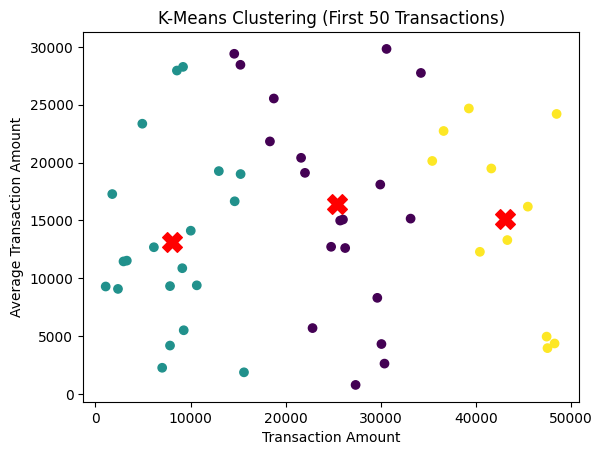

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()


df = pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv").head(50)

X = df[["transaction_amount", "avg_transaction_amount"]]

kmeans = KMeans(n_clusters=3, random_state=0)

df["Cluster"] = kmeans.fit_predict(X)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

plt.figure()

plt.scatter(df["transaction_amount"],
            df["avg_transaction_amount"],
            c=df["Cluster"])

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            color="red",
            marker="X",
            s=200)

plt.xlabel("Transaction Amount")

plt.ylabel("Average Transaction Amount")

plt.title("K-Means Clustering (First 50 Transactions)")

plt.show()

Accuracy: 0.1

Classification Report:

              precision    recall  f1-score   support

          17       0.00      0.00      0.00         4
          18       0.00      0.00      0.00         0
          19       0.11      0.50      0.18         2
          20       0.00      0.00      0.00         3
          21       0.00      0.00      0.00         2
          22       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         6
          24       0.00      0.00      0.00         0
          25       0.33      0.50      0.40         2

    accuracy                           0.10        20
   macro avg       0.05      0.11      0.06        20
weighted avg       0.04      0.10      0.06        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

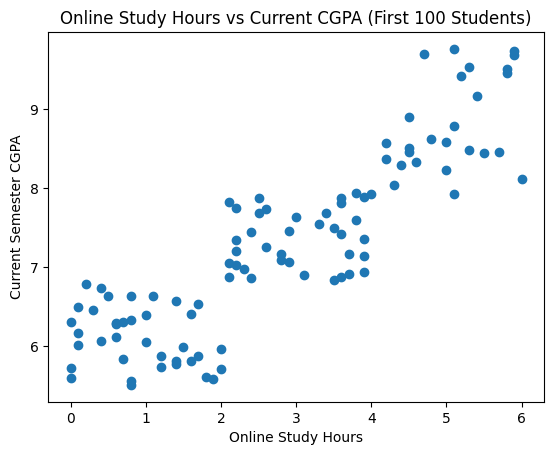

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall()

# Load dataset and select first 100 students
df = pd.read_csv("Student_Performance_2026.csv").head(100)

# Import SVM libraries
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Features and Target
X = df.drop(["Age", "student_ID", "Gender"], axis=1)
y = df["Age"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
model = SVC(kernel="rbf")

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Display Results
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# Graph: Scatter Plot for First 100 Students

plt.figure()

plt.scatter(df["online_study_hours"], df["current_sem_CGPA"])

plt.title("Online Study Hours vs Current CGPA (First 100 Students)")

plt.xlabel("Online Study Hours")

plt.ylabel("Current Semester CGPA")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Prediction: Fail


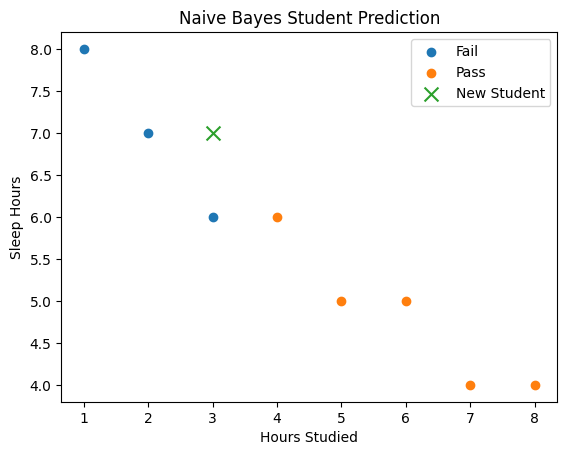

In [6]:
# Naive Bayes with Graph Output

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# Dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Sleep_Hours': [8, 7, 6, 6, 5, 5, 4, 4],
    'Pass': [0, 0, 0, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features and target
X = df[['Hours_Studied', 'Sleep_Hours']]
y = df['Pass']

# Train model
model = GaussianNB()
model.fit(X, y)

# New prediction point
new_data = [[3, 7]]
prediction = model.predict(new_data)

print("Prediction:", "Pass" if prediction[0]==1 else "Fail")

# Plot graph
plt.figure()

# Plot Fail students
fail = df[df['Pass']==0]
plt.scatter(fail['Hours_Studied'], fail['Sleep_Hours'], label="Fail")

# Plot Pass students
passed = df[df['Pass']==1]
plt.scatter(passed['Hours_Studied'], passed['Sleep_Hours'], label="Pass")

# Plot new student
plt.scatter(new_data[0][0], new_data[0][1], marker='x', s=100, label="New Student")

# Labels
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.title("Naive Bayes Student Prediction")

plt.legend()

plt.show()